# Comparing AGN selections on a Euclid Q1 color SOM

*Euclid user-support tutorial - extragalactic use case.*

This notebook builds a compact workflow for using manifold learning to compare Q1 AGN selections in a common galaxy-color space.

**Question.** Where do independently selected AGN candidates lie on the Q1 galaxy color manifold, where do different selection techniques intersect, and which regions are associated with host brightness or survey-photometry context?

**Data used.**
- Matamoro Zatarain et al. (2025) EDF-N/S/F AGN catalogs.
- Euclid Q1 MER template-fit photometry: ancillary optical `griz` plus NISP `YJH`.
- Euclid Q1 PHZ photo-z and H-band physical-parameter fluxes when available.

**Workflow.**
1. Select AGN and reference galaxies in `1.5 < z < 1.8`.
2. Apply the same seven-band S/N and magnitude cuts.
3. Compare the input colors before the SOM.
4. Train a galaxy-only SOM on six adjacent colors.
5. Color the SOM by photo-z and observed $m_H$.
6. Project AGNs and compare photometric-system overlays plus method-specific excess maps.

The central tutorial idea is to use the SOM as an organized, two-dimensional representation of multi-color space. Raw AGN density shows where the union AGN sample occupies this manifold; method-specific excess maps then highlight where each selection technique is relatively concentrated compared with the union AGN population.


In [6]:
# Install Python dependencies into the active kernel.
# Uncomment the next line on first use; comment it out again afterward
# to avoid re-installing on every notebook run.
#%pip install --quiet --upgrade astroquery astropy numpy scipy matplotlib minisom tqdm s3fs requests

In [7]:
# --- standard library --------------------------------------------------------
import os
import warnings

# --- third-party -------------------------------------------------------------
import numpy as np
import scipy.interpolate
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm, Normalize, PowerNorm
from astropy.table import Table, vstack, join
from astropy.utils.metadata import MergeConflictWarning
from astroquery.ipac.irsa import Irsa
from minisom import MiniSom

# --- project: helpers, module constants, and colormaps -----------------------
# Data IO, table utilities, SOM grid arithmetic, plotting helpers, cache
# management, SAS spectrum fetching, and SPE Halpha querying all live in
# agn_tutorial_utils.py. The wildcard import also brings in tqdm.
from agn_tutorial_utils import *

warnings.filterwarnings('ignore', category=MergeConflictWarning)

%matplotlib inline

# --- science choices ---------------------------------------------------------
# Z_WIN = (1.50, 1.80): the narrow window where Halpha, [NII], Hbeta, [OIII],
# and [SII] all fall within the Euclid NISP red grism (1.25-1.85 um), so a
# future extension can fold in spectroscopic BPT diagnostics from SIR data.
# If the projected AGN count is too small for the per-method panels, widen
# to Z_WIN = (0.90, 1.80) -- the full Halpha-in-RGS range -- and accept
# that Hbeta/[OIII] drop out below z = 1.5.
Z_WIN     = (1.50, 1.80)
SNR_MIN   = 5.0               # minimum per-band template-fit S/N
MAG_MIN, MAG_MAX = 12, 30     # sane AB-mag range, to reject bad fluxes
MSZ       = (30, 30)          # SOM grid
N_ITER    = 100_000           # SOM training iterations
TRAIN_N   = 100_000           # max MER reference galaxies to pull from IRSA
QE_PCTILE = 95                # keep AGN projections within the training-manifold QE range
RANDOM_SEED = 0

COLOR_NAMES = ['gr', 'ri', 'iz', 'zy', 'yj', 'jh']
COLOR_LABELS = {
    'gr': r'$g-r$', 'ri': r'$r-i$', 'iz': r'$i-z$',
    'zy': r'$z-Y$', 'yj': r'$Y-J$', 'jh': r'$J-H$',
}

# --- caches ------------------------------------------------------------------
# --- caches --------------------------------------------------------------
DATA_DIR = 'data'
os.makedirs(DATA_DIR, exist_ok=True)
CACHE_AGN   = os.path.join(DATA_DIR, 'tutorial_agn_phot.fits')
CACHE_TRAIN = os.path.join(DATA_DIR, 'tutorial_mer_training.fits')
CACHE_PHYS  = os.path.join(DATA_DIR, 'tutorial_phys.fits')
FORCE_REFRESH = False         # flip True to redo IRSA queries from scratch
print(f'Redshift window: {Z_WIN[0]} < z < {Z_WIN[1]}')
print(f'SOM grid: {MSZ[0]} x {MSZ[1]}; training iterations: {N_ITER:,}')
print(f'Min per-band S/N: {SNR_MIN}; mag range: [{MAG_MIN}, {MAG_MAX}]')


Redshift window: 1.5 < z < 1.8
SOM grid: 30 x 30; training iterations: 100,000
Min per-band S/N: 5.0; mag range: [12, 30]


## 1. Load the AGN catalogs

Load the EDF-N, EDF-S, and EDF-F AGN candidate tables and keep the selection flags used later for grouping. A source can satisfy more than one method, so the per-method counts are not disjoint.


In [8]:
COMMON_FLAGS = [
    'PRF_qso_candidate', 'B24a_qso_candidate',
    'C75_agn_candidate', 'R90_agn_candidate',
    'GDR3_qso_candidate',
    'JH_IeY_qso_candidate', 'IeH_gz_qso_candidate',
]
EDFN_EXTRA = [
    'B24b_qso_candidate',
    'DESI_qso_candidate', 'DESI_broadline_galaxy_candidate', 'DESI_broadline_qso_candidate',
    'DESI_niibpt_agn_candidate', 'DESI_siibpt_agn_candidate', 'DESI_oibpt_agn_candidate',
    'DESI_whan_agn_candidate', 'DESI_blue_agn_candidate', 'DESI_kex_agn_candidate',
    'AGN_sed_candidate',
]
ALL_FLAGS = COMMON_FLAGS + EDFN_EXTRA

GROUPS = {
    'NIR colors (JH-IeY + IeH-gz)':       ['JH_IeY_qso_candidate', 'IeH_gz_qso_candidate'],
    'WISE (C75 + R90)':                   ['C75_agn_candidate', 'R90_agn_candidate'],
    'B24 (B24a + B24b)':                  ['B24a_qso_candidate', 'B24b_qso_candidate'],
    'AGN SED':                            ['AGN_sed_candidate'],
    'PRF':                                ['PRF_qso_candidate'],
    'Gaia DR3':                           ['GDR3_qso_candidate'],
    'DESI spec (all DESI flags)': [
        'DESI_qso_candidate', 'DESI_broadline_galaxy_candidate', 'DESI_broadline_qso_candidate',
        'DESI_niibpt_agn_candidate', 'DESI_siibpt_agn_candidate', 'DESI_oibpt_agn_candidate',
        'DESI_whan_agn_candidate', 'DESI_blue_agn_candidate', 'DESI_kex_agn_candidate',
    ],
}

def load_edf(path, field):
    t = Table.read(path)
    bright = (t['bright_vis_mag_bin']==1) | (t['medium_vis_mag_bin']==1) | (t['faint_vis_mag_bin']==1)
    clean = (t['good_flags']==1) & bright & (t['star_candidate_all']==0)
    t = t[clean]

    any_agn = np.zeros(len(t), dtype=bool)
    for f in COMMON_FLAGS:
        any_agn |= (t[f]==1)
    if field == 'N':
        for f in EDFN_EXTRA:
            any_agn |= (t[f]==1)
    t = t[any_agn]

    keep = ['object_id_euclid', 'ra_euclid', 'dec_euclid'] + COMMON_FLAGS
    if field == 'N':
        keep += ['Z_desi', 'Z_sdss'] + EDFN_EXTRA
    out = t[keep]
    if field != 'N':
        out['Z_desi'] = np.full(len(out), np.nan)
        out['Z_sdss'] = np.full(len(out), np.nan)
        for f in EDFN_EXTRA:
            out[f] = np.zeros(len(out), dtype=np.int8)
    out['field'] = np.full(len(out), field)
    return out

agn = vstack([
    load_edf('data/edfn.fits', 'N'),
    load_edf('data/edfs.fits', 'S'),
    load_edf('data/edff.fits', 'F'),
])
print(f'Combined AGN candidate sample: {len(agn):,} sources (EDF-N + S + F)\n')
print('Per-method counts (a source can be flagged by multiple methods):')
for f in ALL_FLAGS:
    print(f'  {f:42s} {int(np.sum(agn[f]==1)):>8,}')

Combined AGN candidate sample: 229,748 sources (EDF-N + S + F)

Per-method counts (a source can be flagged by multiple methods):
  PRF_qso_candidate                           106,546
  B24a_qso_candidate                           37,807
  C75_agn_candidate                            47,113
  R90_agn_candidate                             4,110
  GDR3_qso_candidate                            1,946
  JH_IeY_qso_candidate                         48,678
  IeH_gz_qso_candidate                         25,010
  B24b_qso_candidate                            9,833
  DESI_qso_candidate                            1,553
  DESI_broadline_galaxy_candidate                 217
  DESI_broadline_qso_candidate                  1,425
  DESI_niibpt_agn_candidate                        95
  DESI_siibpt_agn_candidate                        74
  DESI_oibpt_agn_candidate                        113
  DESI_whan_agn_candidate                       1,818
  DESI_blue_agn_candidate                         254
  DESI_

## 2. Query Q1 photo-z and photometry for AGNs

First fetch PHZ photo-z for all AGN candidates, then fetch MER photometry only for sources in the target redshift window. The optical `griz` columns are ancillary ground-based fluxes delivered in MER; `YJH` are Euclid/NISP. North and south optical systems are kept separate with `phot_system`.


In [9]:
MER_TABLE = 'euclid_q1_mer_catalogue'
PHZ_TABLE = 'euclid_q1_phz_photo_z'
FLUX_COLS = [
    'flux_g_ext_hsc_templfit',       'fluxerr_g_ext_hsc_templfit',
    'flux_r_ext_megacam_templfit',   'fluxerr_r_ext_megacam_templfit',
    'flux_i_ext_panstarrs_templfit', 'fluxerr_i_ext_panstarrs_templfit',
    'flux_z_ext_hsc_templfit',       'fluxerr_z_ext_hsc_templfit',
    'flux_g_ext_decam_templfit',     'fluxerr_g_ext_decam_templfit',
    'flux_r_ext_decam_templfit',     'fluxerr_r_ext_decam_templfit',
    'flux_i_ext_decam_templfit',     'fluxerr_i_ext_decam_templfit',
    'flux_z_ext_decam_templfit',     'fluxerr_z_ext_decam_templfit',
    'flux_y_templfit',               'fluxerr_y_templfit',
    'flux_j_templfit',               'fluxerr_j_templfit',
    'flux_h_templfit',               'fluxerr_h_templfit',
    ]
Z_COL = 'phz_median'
CACHE_AGN_Z = os.path.join(DATA_DIR, 'tutorial_agn_z.fits')  # photo-z lookup for ALL AGN (reusable across z windows)


# --- Stage 1: photo-z for ALL AGN candidates (single column = fast) ---------
if FORCE_REFRESH and os.path.exists(CACHE_AGN_Z):
    os.remove(CACHE_AGN_Z); print(f'FORCE_REFRESH: removed {CACHE_AGN_Z}')

if os.path.exists(CACHE_AGN_Z):
    phot_z = Table.read(CACHE_AGN_Z)
    print(f'Loaded cached AGN photo-z: {len(phot_z):,} rows ({CACHE_AGN_Z})')
else:
    ids_all = np.unique(np.asarray(agn['object_id_euclid'], dtype=np.int64))
    print(f'Stage 1: fetching photo-z for all {len(ids_all):,} AGN candidates...')
    phot_z = batched_query(PHZ_TABLE, [Z_COL], ids_all, desc='AGN photo-z')
    phot_z.write(CACHE_AGN_Z, overwrite=True)
    print(f'  -> cached to {CACHE_AGN_Z}')

# --- Assemble z_final per source, filter to z window ------------------------
phot_z_j = phot_z.copy()
if 'object_id' in phot_z_j.colnames:
    phot_z_j.rename_column('object_id', 'object_id_euclid')
agn_z = join(agn, phot_z_j, keys='object_id_euclid', join_type='left')

z_spec = np.array(agn_z['Z_desi'], dtype=float)  # EDF-N only; NaN elsewhere
bad = ~np.isfinite(z_spec) | (z_spec <= 0)
z_spec[bad] = np.array(agn_z['Z_sdss'], dtype=float)[bad]
z_phot = np.array(agn_z[Z_COL], dtype=float)
agn_z['z_final']  = np.where(np.isfinite(z_spec) & (z_spec > 0), z_spec, z_phot)
agn_z['z_source'] = np.where(np.isfinite(z_spec) & (z_spec > 0), 'spec', 'phot')

in_z = np.isfinite(agn_z['z_final']) & (agn_z['z_final'] > Z_WIN[0]) & (agn_z['z_final'] < Z_WIN[1])
agn_in_z = agn_z[in_z]
n_spec = int(np.sum(agn_in_z['z_source']=='spec'))
n_phot = int(np.sum(agn_in_z['z_source']=='phot'))
print(f'\nAGN in {Z_WIN[0]} < z < {Z_WIN[1]}: {len(agn_in_z):,} '
      f'(spec-z: {n_spec:,}; photo-z: {n_phot:,})')

# --- Stage 2: MER photometry for the in-z subset only -----------------------
if FORCE_REFRESH and os.path.exists(CACHE_AGN):
    os.remove(CACHE_AGN); print(f'FORCE_REFRESH: removed {CACHE_AGN}')

if os.path.exists(CACHE_AGN):
    phot = Table.read(CACHE_AGN)
    print(f'\nLoaded cached AGN MER photometry: {len(phot):,} rows ({CACHE_AGN})')
else:
    ids_in_z = np.asarray(agn_in_z['object_id_euclid'], dtype=np.int64)
    print(f'\nStage 2: fetching MER photometry for {len(ids_in_z):,} in-z AGN candidates...')
    phot = batched_query(MER_TABLE, FLUX_COLS, ids_in_z, desc='AGN MER phot')
    phot.write(CACHE_AGN, overwrite=True)
    print(f'  -> cached to {CACHE_AGN}')


Loaded cached AGN photo-z: 229,008 rows (data/tutorial_agn_z.fits)

AGN in 1.5 < z < 1.8: 44,095 (spec-z: 544; photo-z: 43,551)

Loaded cached AGN MER photometry: 44,095 rows (data/tutorial_agn_phot.fits)


In [10]:
# Merge MER photometry onto the in-z AGN table (z_final/z_source were already
# assembled in the previous cell). Then coalesce filter systems, compute colors,
# and apply the 7-band S/N gate.
if 'object_id' in phot.colnames:
    phot.rename_column('object_id', 'object_id_euclid')
merged = join(agn_in_z, phot, keys='object_id_euclid', join_type='inner')

# Coalesce HSC/Megacam/PanSTARRS (EDF-N native) <- DECam (EDF-S/F native) per band
gf, ge, gsys = coalesce(merged, 'flux_g_ext_hsc_templfit',       'flux_g_ext_decam_templfit')
rf, re_, _   = coalesce(merged, 'flux_r_ext_megacam_templfit',   'flux_r_ext_decam_templfit')
if_, ie, _   = coalesce(merged, 'flux_i_ext_panstarrs_templfit', 'flux_i_ext_decam_templfit')
zf, ze, _    = coalesce(merged, 'flux_z_ext_hsc_templfit',       'flux_z_ext_decam_templfit')
yf = np.asarray(merged['flux_y_templfit'], float); ye = np.asarray(merged['fluxerr_y_templfit'], float)
jf = np.asarray(merged['flux_j_templfit'], float); je = np.asarray(merged['fluxerr_j_templfit'], float)
hf = np.asarray(merged['flux_h_templfit'], float); he = np.asarray(merged['fluxerr_h_templfit'], float)

g, r, i, z = abmag(gf), abmag(rf), abmag(if_), abmag(zf)
y, j, h    = abmag(yf), abmag(jf), abmag(hf)
snr_ok = (
    (snr(gf, ge)  > SNR_MIN) & (snr(rf, re_) > SNR_MIN) & (snr(if_, ie) > SNR_MIN) &
    (snr(zf, ze)  > SNR_MIN) & (snr(yf, ye)  > SNR_MIN) & (snr(jf, je) > SNR_MIN) &
    (snr(hf, he)  > SNR_MIN)
)
mag_ok = (
    (g > MAG_MIN) & (r > MAG_MIN) & (i > MAG_MIN) & (z > MAG_MIN) &
    (y > MAG_MIN) & (j > MAG_MIN) & (h > MAG_MIN) &
    (g < MAG_MAX) & (r < MAG_MAX) & (i < MAG_MAX) & (z < MAG_MAX) &
    (y < MAG_MAX) & (j < MAG_MAX) & (h < MAG_MAX)
)
merged['phot_ok'] = snr_ok & mag_ok
merged['phot_system'] = gsys
merged['gr'], merged['ri'], merged['iz'] = g-r, r-i, i-z
merged['zy'], merged['yj'], merged['jh'] = z-y, y-j, j-h

agn_sel = merged[merged['phot_ok']]
print(f'AGN with full 7-band S/N>{SNR_MIN} photometry in z window: {len(agn_sel):,}')
print(f'  spec-z: {int(np.sum(agn_sel["z_source"]=="spec")):,}')
print(f'  photo-z: {int(np.sum(agn_sel["z_source"]=="phot")):,}')
print(f'  phot system: north {int(np.sum(agn_sel["phot_system"]=="north")):,}'
      f' / south {int(np.sum(agn_sel["phot_system"]=="south")):,}')


AGN with full 7-band S/N>5.0 photometry in z window: 7,841
  spec-z: 489
  photo-z: 7,352
  phot system: north 2,498 / south 5,343


## 3. Build the reference galaxy sample

The SOM is trained on Q1 galaxies in the same redshift window after applying consistent MER/PHZ quality, morphology, and S/N cuts. Using a galaxy reference sample defines the manifold from the broader galaxy population first; AGN candidates are then projected onto that fixed manifold so their locations can be compared across selection techniques.


In [11]:
MER_FLUX_SQL = ',\n  '.join([f'm.{c}' for c in FLUX_COLS])
FLUX_MIN_VIS = 10 ** ((23.9 - 24.5) / 2.5)   # 0.575 uJy <=> I_E < 24.5

TRAIN_QUERY = f"""
SELECT TOP {TRAIN_N} m.object_id, m.ra, m.dec,
  {MER_FLUX_SQL},
  p.phz_median
FROM {MER_TABLE}  AS m
JOIN {PHZ_TABLE}  AS p ON m.object_id = p.object_id
WHERE p.phz_median BETWEEN {Z_WIN[0]} AND {Z_WIN[1]}
  AND p.phz_flags = 0
  AND m.flag_vis = 0
  AND m.det_quality_flag < 4
  AND m.spurious_flag = 0
  AND m.mumax_minus_mag > -2.6
  AND m.flux_detection_total > {FLUX_MIN_VIS}
ORDER BY m.object_id
"""

if FORCE_REFRESH and os.path.exists(CACHE_TRAIN):
    os.remove(CACHE_TRAIN); print(f'FORCE_REFRESH: removed {CACHE_TRAIN}')

if os.path.exists(CACHE_TRAIN):
    train = Table.read(CACHE_TRAIN)
    print(f'Loaded cached training sample: {len(train):,} rows ({CACHE_TRAIN})')
else:
    # A JOIN across the full MER + PHZ tables exceeds IRSA's sync-query budget,
    # so we submit it as an async TAP job. The block returns when the job completes
    # (typically 1-3 min for TRAIN_N = 100k).
    print(f'Submitting async MER+PHZ JOIN query for up to {TRAIN_N:,} galaxies in {Z_WIN}...')
    print(TRAIN_QUERY)
    train = Irsa.query_tap(TRAIN_QUERY, async_job=True).to_table()
    train.write(CACHE_TRAIN, overwrite=True)
    print(f'Got {len(train):,} galaxies; cached -> {CACHE_TRAIN}')

# Apply the same per-band coalesce + S/N + mag gate as we did for AGN, in-table
gf, ge, gsys = coalesce(train, 'flux_g_ext_hsc_templfit',       'flux_g_ext_decam_templfit')
rf, re_, _   = coalesce(train, 'flux_r_ext_megacam_templfit',   'flux_r_ext_decam_templfit')
if_, ie, _   = coalesce(train, 'flux_i_ext_panstarrs_templfit', 'flux_i_ext_decam_templfit')
zf, ze, _    = coalesce(train, 'flux_z_ext_hsc_templfit',       'flux_z_ext_decam_templfit')
yf = np.asarray(train['flux_y_templfit'], float); ye = np.asarray(train['fluxerr_y_templfit'], float)
jf = np.asarray(train['flux_j_templfit'], float); je = np.asarray(train['fluxerr_j_templfit'], float)
hf = np.asarray(train['flux_h_templfit'], float); he = np.asarray(train['fluxerr_h_templfit'], float)

g, r, i, z = abmag(gf), abmag(rf), abmag(if_), abmag(zf)
y, j, h    = abmag(yf), abmag(jf), abmag(hf)
snr_ok = (
    (snr(gf, ge)  > SNR_MIN) & (snr(rf, re_) > SNR_MIN) & (snr(if_, ie) > SNR_MIN) &
    (snr(zf, ze)  > SNR_MIN) & (snr(yf, ye)  > SNR_MIN) & (snr(jf, je) > SNR_MIN) &
    (snr(hf, he)  > SNR_MIN)
)
mag_ok = (
    (g > MAG_MIN) & (r > MAG_MIN) & (i > MAG_MIN) & (z > MAG_MIN) &
    (y > MAG_MIN) & (j > MAG_MIN) & (h > MAG_MIN) &
    (g < MAG_MAX) & (r < MAG_MAX) & (i < MAG_MAX) & (z < MAG_MAX) &
    (y < MAG_MAX) & (j < MAG_MAX) & (h < MAG_MAX)
)
train['phot_ok'] = snr_ok & mag_ok
train['phot_system'] = gsys
train['gr'], train['ri'], train['iz'] = g-r, r-i, i-z
train['zy'], train['yj'], train['jh'] = z-y, y-j, j-h
train_ok = train[train['phot_ok']]
print(f'\nTraining sample with full 7-band S/N>{SNR_MIN} photometry: {len(train_ok):,}')
print(f'  phot system: north {int(np.sum(train_ok["phot_system"]=="north")):,}'
      f' / south {int(np.sum(train_ok["phot_system"]=="south")):,}')


Loaded cached training sample: 100,000 rows (data/tutorial_mer_training.fits)

Training sample with full 7-band S/N>5.0 photometry: 48,871
  phot system: north 0 / south 48,871


## 4. Host-brightness proxy

Use observed-frame H-band AB magnitude, $m_H$, as a simple host-brightness proxy. PHZ `flux_h_total_corrected` is preferred when available; the notebook falls back to MER `flux_h_templfit` so each plotted source can use an available H-band measurement. This is not a stellar mass estimate.


In [12]:
PHYS_TABLE = 'euclid_q1_phz_nir_physical_parameters'
PHYS_COLS = ['flux_h_total_corrected', 'fluxerr_h_total_corrected']

ids_train = np.asarray(train_ok['object_id'], dtype=np.int64)
ids_agn   = np.asarray(agn_sel['object_id_euclid'], dtype=np.int64)
ids_all   = np.unique(np.concatenate([ids_train, ids_agn]))

if FORCE_REFRESH and os.path.exists(CACHE_PHYS):
    os.remove(CACHE_PHYS); print(f'FORCE_REFRESH: removed {CACHE_PHYS}')

if os.path.exists(CACHE_PHYS):
    phys = Table.read(CACHE_PHYS)
    cached_ids = np.asarray(phys['object_id'], dtype=np.int64) if 'object_id' in phys.colnames else np.array([], dtype=np.int64)
    missing_ids = np.setdiff1d(ids_all, cached_ids, assume_unique=False)
    print(f'Loaded cached NIR phys-params: {len(phys):,} rows ({CACHE_PHYS})')
    if missing_ids.size:
        print(f'  cache is missing {missing_ids.size:,} requested IDs; those rows will use MER H fallback')
        print('  set FORCE_REFRESH = True to rebuild the PHYS cache from IRSA')
else:
    print(f'Fetching extinction-corrected H-band fluxes for {len(ids_all):,} unique IDs...')
    phys = batched_query(PHYS_TABLE, PHYS_COLS, ids_all, desc='NIR phys params')
    phys.write(CACHE_PHYS, overwrite=True)
    print(f'Cached -> {CACHE_PHYS} ({len(phys):,} rows)')

# Keep only sources with finite, positive H-band flux; compute observed-frame H AB magnitude.
phys_h = as_float_array(phys['flux_h_total_corrected'])
phys_q = phys[np.isfinite(phys_h) & (phys_h > 0)].copy()
phys_q['mH_obs'] = abmag(as_float_array(phys_q['flux_h_total_corrected']))
phys_pick = phys_q[['object_id', 'flux_h_total_corrected', 'mH_obs']]
print(f'  with positive PHYS flux_h: {len(phys_q):,}')
if len(phys_q):
    print(f'  PHYS observed mH range: [{float(np.nanmin(phys_q["mH_obs"])):.2f}, {float(np.nanmax(phys_q["mH_obs"])):.2f}]')

# Join onto training and AGN tables.
train_full = join(train_ok, phys_pick, keys='object_id', join_type='left')
phys_for_agn = phys_pick.copy()
phys_for_agn.rename_column('object_id', 'object_id_euclid')
agn_full = join(agn_sel, phys_for_agn, keys='object_id_euclid', join_type='left')

# Left joins produce masked entries where PHYS has no row. Preserve those as NaN,
# then fill missing values from the MER H-band flux already used in the color cuts.
mH_train_phys = as_float_array(train_full['mH_obs'])
mH_agn_phys   = as_float_array(agn_full['mH_obs'])
mH_train_mer  = abmag(as_float_array(train_full['flux_h_templfit']))
mH_agn_mer    = abmag(as_float_array(agn_full['flux_h_templfit']))

mH_train = mH_train_phys.copy()
mH_agn   = mH_agn_phys.copy()
use_train_mer = ~np.isfinite(mH_train) & valid_mag(mH_train_mer)
use_agn_mer   = ~np.isfinite(mH_agn)   & valid_mag(mH_agn_mer)
mH_train[use_train_mer] = mH_train_mer[use_train_mer]
mH_agn[use_agn_mer]     = mH_agn_mer[use_agn_mer]
train_full['mH_obs'] = mH_train
agn_full['mH_obs']   = mH_agn

n_train_phys = int(np.sum(np.isfinite(mH_train_phys)))
n_agn_phys   = int(np.sum(np.isfinite(mH_agn_phys)))
n_train_ok   = int(np.sum(np.isfinite(mH_train)))
n_agn_ok     = int(np.sum(np.isfinite(mH_agn)))
print(f'\nTraining galaxies with mH_obs: {n_train_ok:,} / {len(train_full):,} '
      f'({n_train_phys:,} PHYS; {int(np.sum(use_train_mer)):,} MER fallback)')
print(f'AGN candidates with mH_obs:   {n_agn_ok:,} / {len(agn_full):,} '
      f'({n_agn_phys:,} PHYS; {int(np.sum(use_agn_mer)):,} MER fallback)')


Loaded cached NIR phys-params: 21 rows (data/tutorial_phys.fits)
  cache is missing 54,608 requested IDs; those rows will use MER H fallback
  set FORCE_REFRESH = True to rebuild the PHYS cache from IRSA
  with positive PHYS flux_h: 21
  PHYS observed mH range: [20.33, 21.64]

Training galaxies with mH_obs: 48,871 / 48,871 (0 PHYS; 48,871 MER fallback)
AGN candidates with mH_obs:   7,841 / 7,841 (21 PHYS; 7,820 MER fallback)


### Check the input colors before the SOM

Before interpreting the SOM, compare the six input colors for the reference galaxies and AGNs. This establishes the color range covered by each sample and shows how the AGN candidates extend through color space before the manifold projection.


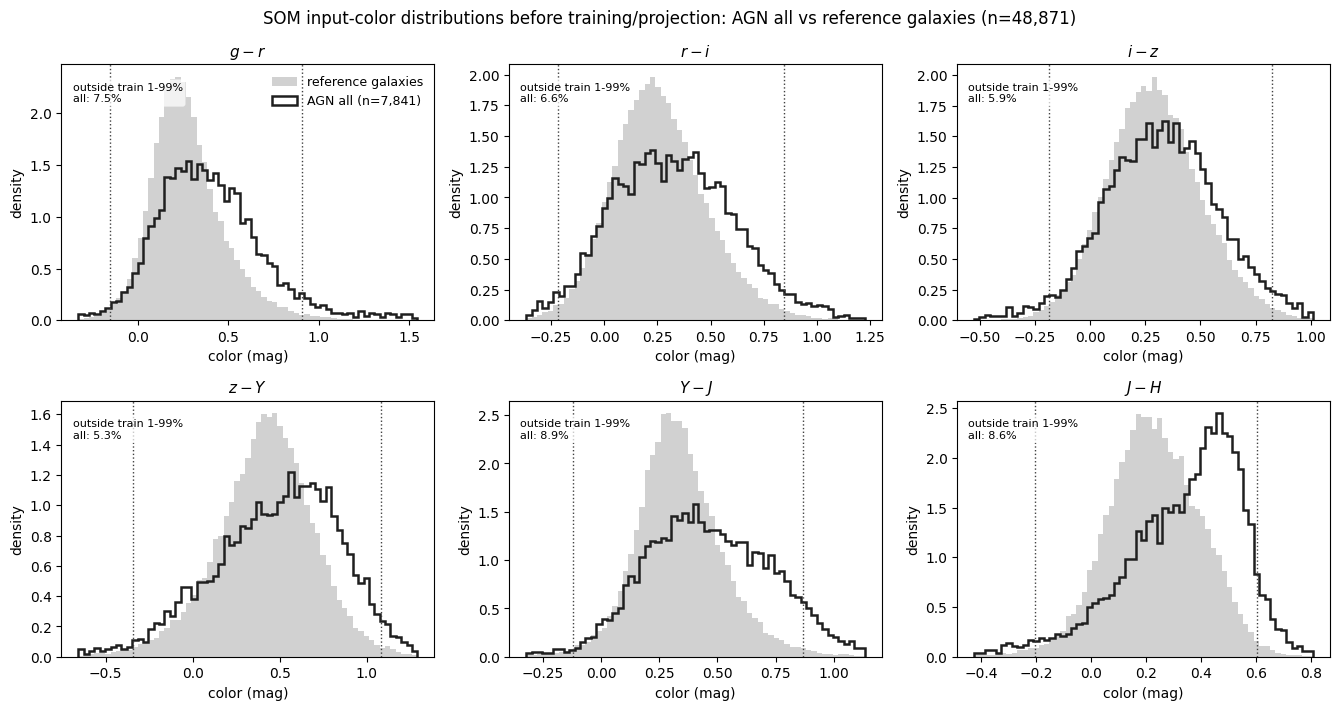

In [13]:
COLOR_DIAG_AGN_SYSTEMS = ['all']  # choose from 'south', 'north', 'all'
COLOR_DIAG_BINS = 64

color_systems = [COLOR_DIAG_AGN_SYSTEMS] if isinstance(COLOR_DIAG_AGN_SYSTEMS, str) else list(COLOR_DIAG_AGN_SYSTEMS)
color_styles = {
    'south': dict(color='#8a1c7c', linestyle='-',  label='AGN south'),
    'north': dict(color='#0f7f8c', linestyle='--', label='AGN north'),
    'all':   dict(color='#1f1f1f', linestyle='-',  label='AGN all'),
}
color_samples = []
for system in color_systems:
    if system == 'all':
        mask = np.ones(len(agn_full), dtype=bool)
    else:
        mask = np.asarray(agn_full['phot_system'], dtype=str) == system
    color_samples.append((system, agn_full[mask], color_styles.get(system, dict(label=f'AGN {system}'))))
color_save_suffix = '_'.join(color_systems)
fig, axes = plt.subplots(2, 3, figsize=(13.5, 7.2), sharey=False)
axes = axes.ravel()
for ax, cname in zip(axes, COLOR_NAMES):
    v_train = as_float_array(train_full[cname])
    v_train = v_train[np.isfinite(v_train)]
    agn_values = []
    for system, sample, style in color_samples:
        v = as_float_array(sample[cname])
        v = v[np.isfinite(v)]
        if v.size:
            agn_values.append((system, v, style))
    if (v_train.size == 0) or (len(agn_values) == 0):
        ax.text(0.5, 0.5, 'no finite values', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(COLOR_LABELS.get(cname, cname))
        continue

    train_lo, train_hi = np.nanpercentile(v_train, [1, 99])
    plot_lo = min([np.nanpercentile(v_train, 0.5)] + [np.nanpercentile(v, 0.5) for _, v, _ in agn_values])
    plot_hi = max([np.nanpercentile(v_train, 99.5)] + [np.nanpercentile(v, 99.5) for _, v, _ in agn_values])
    if plot_lo == plot_hi:
        plot_lo -= 0.05; plot_hi += 0.05
    bins = np.linspace(plot_lo, plot_hi, COLOR_DIAG_BINS)

    ax.hist(v_train, bins=bins, density=True, color='0.76', alpha=0.75,
            label='reference galaxies')
    stat_lines = []
    for system, v_agn, style in agn_values:
        ax.hist(v_agn, bins=bins, density=True, histtype='step',
                color=style.get('color', 'black'), linestyle=style.get('linestyle', '-'),
                linewidth=1.8, label=f"{style.get('label', system)} (n={len(v_agn):,})")
        outside = np.mean((v_agn < train_lo) | (v_agn > train_hi))
        stat_lines.append(f"{style.get('label', system).replace('AGN ', '')}: {outside*100:.1f}%")
    ax.axvline(train_lo, color='0.25', linestyle=':', linewidth=1.0)
    ax.axvline(train_hi, color='0.25', linestyle=':', linewidth=1.0)

    ax.text(0.03, 0.93, 'outside train 1-99%\n' + '\n'.join(stat_lines),
            transform=ax.transAxes, ha='left', va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.72, edgecolor='none'))
    ax.set_title(COLOR_LABELS.get(cname, cname), fontsize=11)
    ax.set_xlabel('color (mag)')
    ax.set_ylabel('density')

axes[0].legend(frameon=False, fontsize=9, loc='upper right')
fig.suptitle(f'SOM input-color distributions before training/projection: AGN {", ".join(color_systems)} '
             f'vs reference galaxies (n={len(train_full):,})', fontsize=12)
plt.tight_layout()
plt.show()


## 5. Train the SOM

Train the SOM on six adjacent colors: `g-r`, `r-i`, `i-z`, `z-Y`, `Y-J`, and `J-H`. The features are z-score normalized using the reference galaxy sample. The trained SOM is therefore a galaxy color manifold; AGNs are projected onto it afterward.


In [14]:
X_train = np.vstack([train_full[c] for c in COLOR_NAMES]).T
X_train = X_train[np.all(np.isfinite(X_train), axis=1)]

mu    = np.nanmean(X_train, axis=0)
sigma = np.nanstd(X_train, axis=0); sigma[sigma == 0] = 1.0
Xn    = (X_train - mu) / sigma

som = MiniSom(MSZ[0], MSZ[1], len(COLOR_NAMES), sigma=10.0, learning_rate=0.1, random_seed=RANDOM_SEED)
som.random_weights_init(Xn)
print(f'Training SOM on {len(Xn):,} Euclid galaxies, {N_ITER:,} iterations...')
som.train_random(Xn, N_ITER)

weights = som.get_weights()
bmu_train = np.array([som.winner(v) for v in Xn])
qe_train  = np.linalg.norm(Xn - weights[bmu_train[:,0], bmu_train[:,1]], axis=1)
qe_thresh = float(np.percentile(qe_train, QE_PCTILE))
print(f'Training quantization error (mean / median / 95th pct): '
      f'{qe_train.mean():.3f} / {np.median(qe_train):.3f} / {qe_thresh:.3f}')


Training SOM on 48,871 Euclid galaxies, 100,000 iterations...
Training quantization error (mean / median / 95th pct): 1.186 / 1.017 / 2.409


## 6. Color the SOM by photo-z and $m_H$

These backgrounds make the manifold interpretable. The photo-z map checks whether the SOM is mostly redshift stratification. The $m_H$ map provides a host-brightness view within the narrow redshift slice.


Median-z range across cells: [1.53, 1.74]
Median-mH range across cells: [21.36, 23.11]


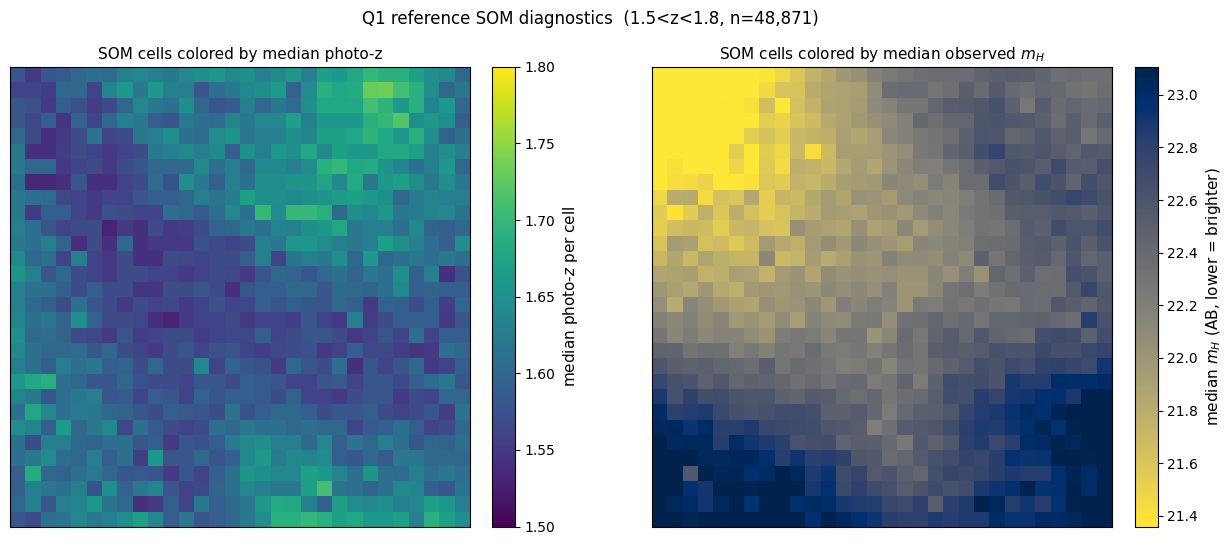

In [15]:
# BMU for the *full* training sample (including those without mH_obs)
X_full_train = np.vstack([train_full[c] for c in COLOR_NAMES]).T
keep = np.all(np.isfinite(X_full_train), axis=1)
Xn_full = (X_full_train[keep] - mu) / sigma
bmu_full = np.array([som.winner(v) for v in Xn_full])
train_use = train_full[keep]

med_z   = median_map(train_use['phz_median'], bmu_full)
med_mH  = median_map(train_use['mH_obs'],     bmu_full)
if not np.isfinite(med_mH).any():
    raise RuntimeError('No finite mH_obs values are available for the SOM cells; check the PHYS cache and MER H fallback.')
mH_lo, mH_hi = np.nanpercentile(med_mH, [5, 95])
if (not np.isfinite(mH_lo)) or (not np.isfinite(mH_hi)) or (mH_lo == mH_hi):
    mH_mid = float(np.nanmedian(med_mH))
    mH_lo, mH_hi = mH_mid - 0.05, mH_mid + 0.05
print(f'Median-z range across cells: [{np.nanmin(med_z):.2f}, {np.nanmax(med_z):.2f}]')
print(f'Median-mH range across cells: [{mH_lo:.2f}, {mH_hi:.2f}]')

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Panel 1: median photo-z
cf1 = axes[0].imshow(fill_nan_nearest(med_z), origin='lower', cmap='viridis',
                     vmin=Z_WIN[0], vmax=Z_WIN[1])
plt.colorbar(cf1, ax=axes[0], fraction=0.046, pad=0.04).set_label(
    r'median photo-$z$ per cell', fontsize=11)
axes[0].set_title('SOM cells colored by median photo-z', fontsize=11)

# Panel 2: median observed-H AB mag (invert so bright/luminous => light color)
cf2 = axes[1].imshow(fill_nan_nearest(med_mH), origin='lower', cmap='cividis_r',
                     vmin=mH_lo, vmax=mH_hi)
plt.colorbar(cf2, ax=axes[1], fraction=0.046, pad=0.04).set_label(
    r'median $m_H$ (AB, lower = brighter)', fontsize=11)
axes[1].set_title(r'SOM cells colored by median observed $m_H$', fontsize=11)

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle(f'Q1 reference SOM diagnostics  ({Z_WIN[0]}<z<{Z_WIN[1]}, n={len(train_use):,})', fontsize=12)
plt.tight_layout()
plt.show()


**Figure 1.** Reference-galaxy SOM diagnostics. The photo-z panel checks for redshift structure. The $m_H$ panel shows where brighter host galaxies sit on the same color manifold.


## 7. Project AGNs onto the SOM

Project AGNs using the same color normalization as the reference sample. The quantization-error threshold keeps the overlay maps focused on the part of color space represented by the trained galaxy manifold; sources outside that range are counted separately.


In [16]:
ok_a, bmu_a, qe_a = project(agn_full, som, mu, sigma)
agn_proj = agn_full[ok_a]
inlier = qe_a <= qe_thresh
n_out = int(np.sum(~inlier))
bmu_in = bmu_a[inlier]
agn_in = agn_proj[inlier]
print(f'AGN projected:              {len(agn_proj):,}')
print(f'  inliers (QE <= {qe_thresh:.2f}): {len(agn_in):,}')
print(f'  outside training manifold:  {n_out:,}')


AGN projected:              7,841
  inliers (QE <= 2.41): 6,272
  outside training manifold:  1,569


AGN overlay sample: all photometric systems, n=6,272 / 6,272 inliers
  density overlay limits: 2.72-44.94 smoothed AGN/cell (vmin=18th pct/floor, vmax=98.0th pct)


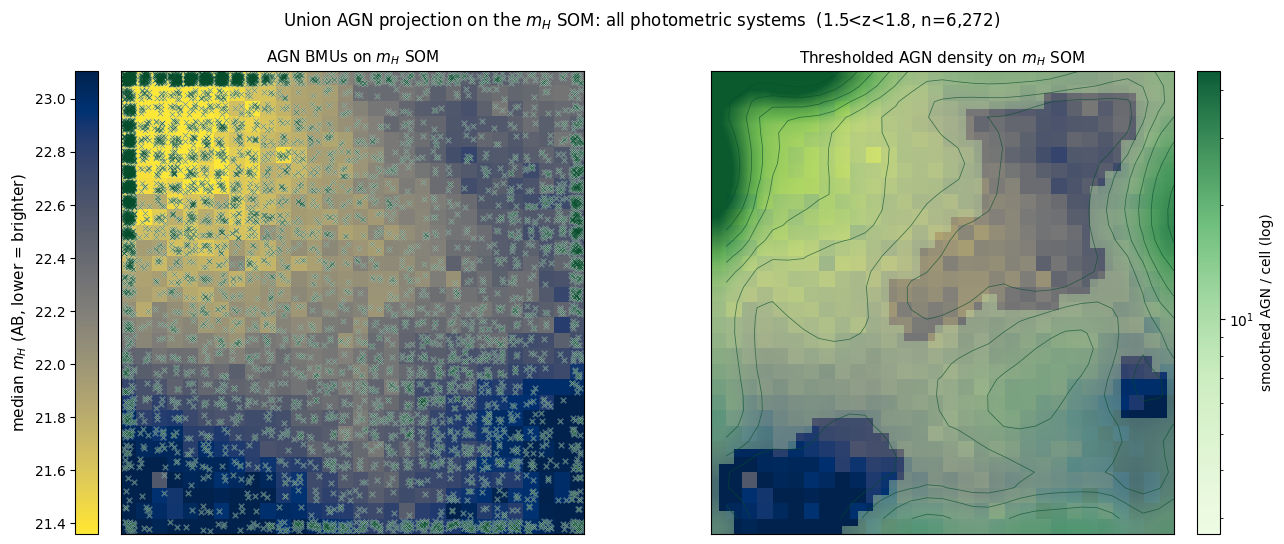

In [17]:
AGN_OVERLAY_SYSTEMS = ['all']  # choose any of 'south', 'north', 'all'

mH_bg = fill_nan_nearest(med_mH)
overlay_systems = [AGN_OVERLAY_SYSTEMS] if isinstance(AGN_OVERLAY_SYSTEMS, str) else list(AGN_OVERLAY_SYSTEMS)

def plot_agn_union(system):
    if system == 'all':
        overlay_mask = np.ones(len(agn_in), dtype=bool)
        overlay_label = 'all photometric systems'
        save_suffix = 'all'
    else:
        overlay_mask = np.asarray(agn_in['phot_system'], dtype=str) == system
        overlay_label = f'{system} photometric system'
        save_suffix = system
    bmu_plot = bmu_in[overlay_mask]
    agn_plot = agn_in[overlay_mask]
    print(f'AGN overlay sample: {overlay_label}, n={len(agn_plot):,} / {len(agn_in):,} inliers')

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

    # Left: individual AGN BMUs on the median-mH background.
    cf1 = axes[0].imshow(mH_bg, origin='lower', cmap='cividis_r', vmin=mH_lo, vmax=mH_hi)
    plt.colorbar(cf1, ax=axes[0], fraction=0.046, pad=0.04, location='left').set_label(
        r'median $m_H$ (AB, lower = brighter)', fontsize=11)
    H = bmu_density(bmu_plot, None)
    x_agn, y_agn = jitter_bmu(bmu_plot)
    axes[0].scatter(x_agn, y_agn, marker='x', s=15, linewidths=1.05,
                    color='white', alpha=0.45)
    axes[0].scatter(x_agn, y_agn, marker='x', s=15, linewidths=0.55,
                    color=AGN_OVERLAY_COLOR, alpha=0.55)
    axes[0].set_title(r'AGN BMUs on $m_H$ SOM', fontsize=11)

    # Right: thresholded AGN-density overlay on the same median-mH background.
    axes[1].imshow(mH_bg, origin='lower', cmap='cividis_r', vmin=mH_lo, vmax=mH_hi)
    if H is not None:
        d2, dens_cut, dens_vmax = overlay(axes[1], H)
        if d2 is not None:
            plt.colorbar(d2, ax=axes[1], fraction=0.046, pad=0.04, location='right').set_label(
                'smoothed AGN / cell (log)', fontsize=10)
            print(f'  density overlay limits: {dens_cut:.2f}-{dens_vmax:.2f} smoothed AGN/cell '
                  f'(vmin={DENSITY_PCTILE}th pct/floor, vmax={DENSITY_VMAX_PCTILE}th pct)')
    axes[1].set_title(r'Thresholded AGN density on $m_H$ SOM', fontsize=11)

    for ax in axes:
        ax.set_xlim(-0.5, MSZ[1]-0.5); ax.set_ylim(-0.5, MSZ[0]-0.5)
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f'Union AGN projection on the $m_H$ SOM: {overlay_label}  '
                 f'({Z_WIN[0]}<z<{Z_WIN[1]}, n={len(agn_plot):,})', fontsize=12)
    plt.tight_layout()
    plt.show()

for system in overlay_systems:
    plot_agn_union(system)


**Figure 2.** AGN projections on the median-$m_H$ SOM, combining the south and north photometric systems. The left panel shows individual BMUs; the right panel shows smoothed density with percentile-limited green color scaling.


## 8. Compare selection methods

The common SOM projection makes it possible to compare several AGN-selection techniques on the same learned color manifold. These panels show where each method is locally enriched relative to the union AGN distribution for the same photometric system, highlighting both shared regions and method-specific concentrations.


Method-excess baseline: all photometric systems, n=6,272 AGN inliers
  independent panel colorbars; BMU x markers shown for n <= 40


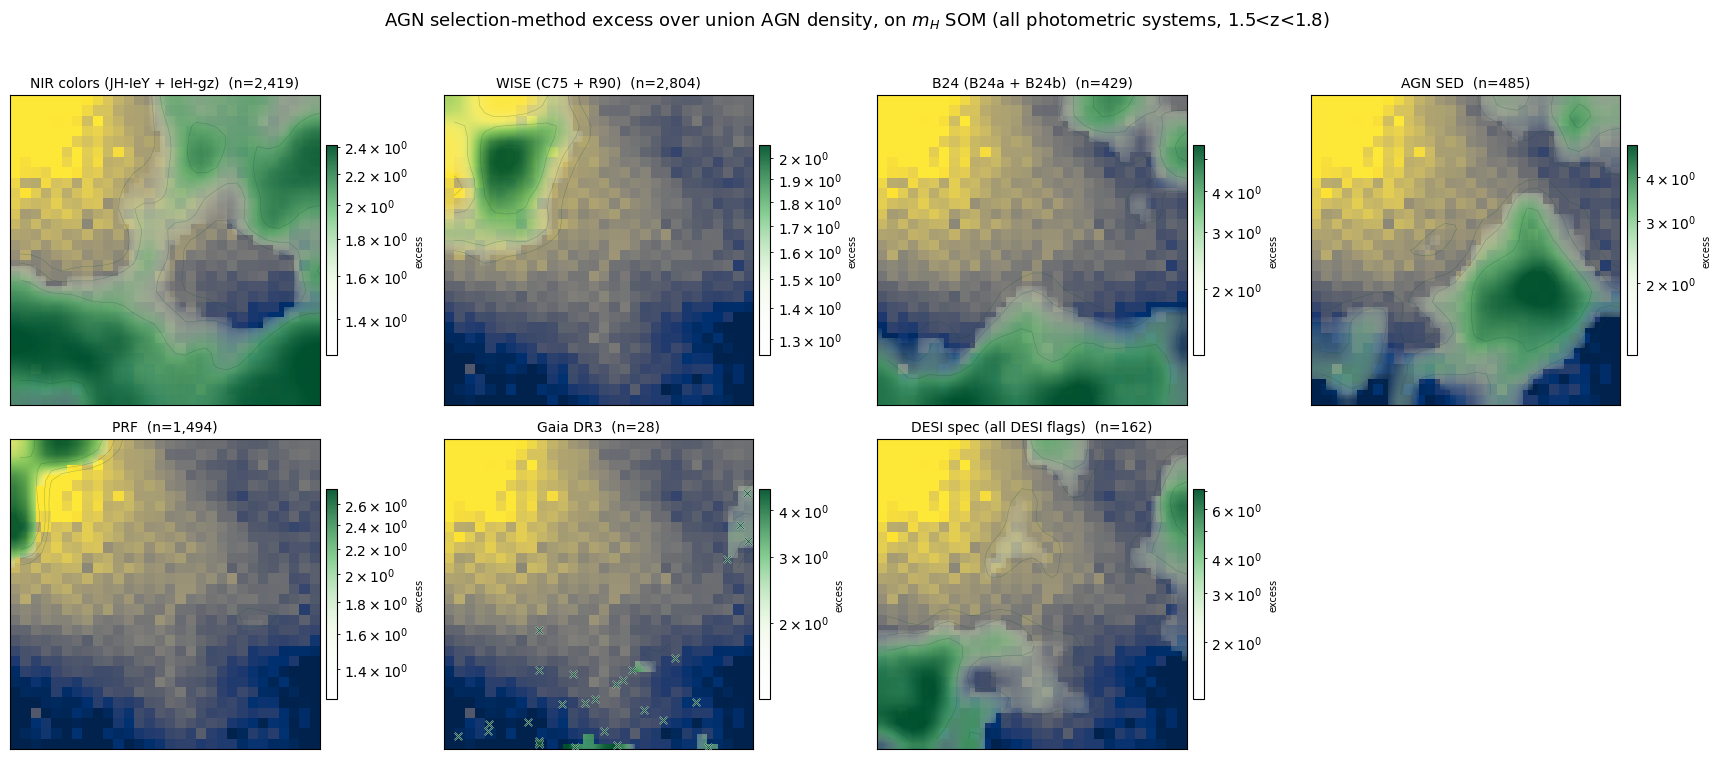

Method-excess baseline: south photometric system, n=4,493 AGN inliers
  independent panel colorbars; BMU x markers shown for n <= 40


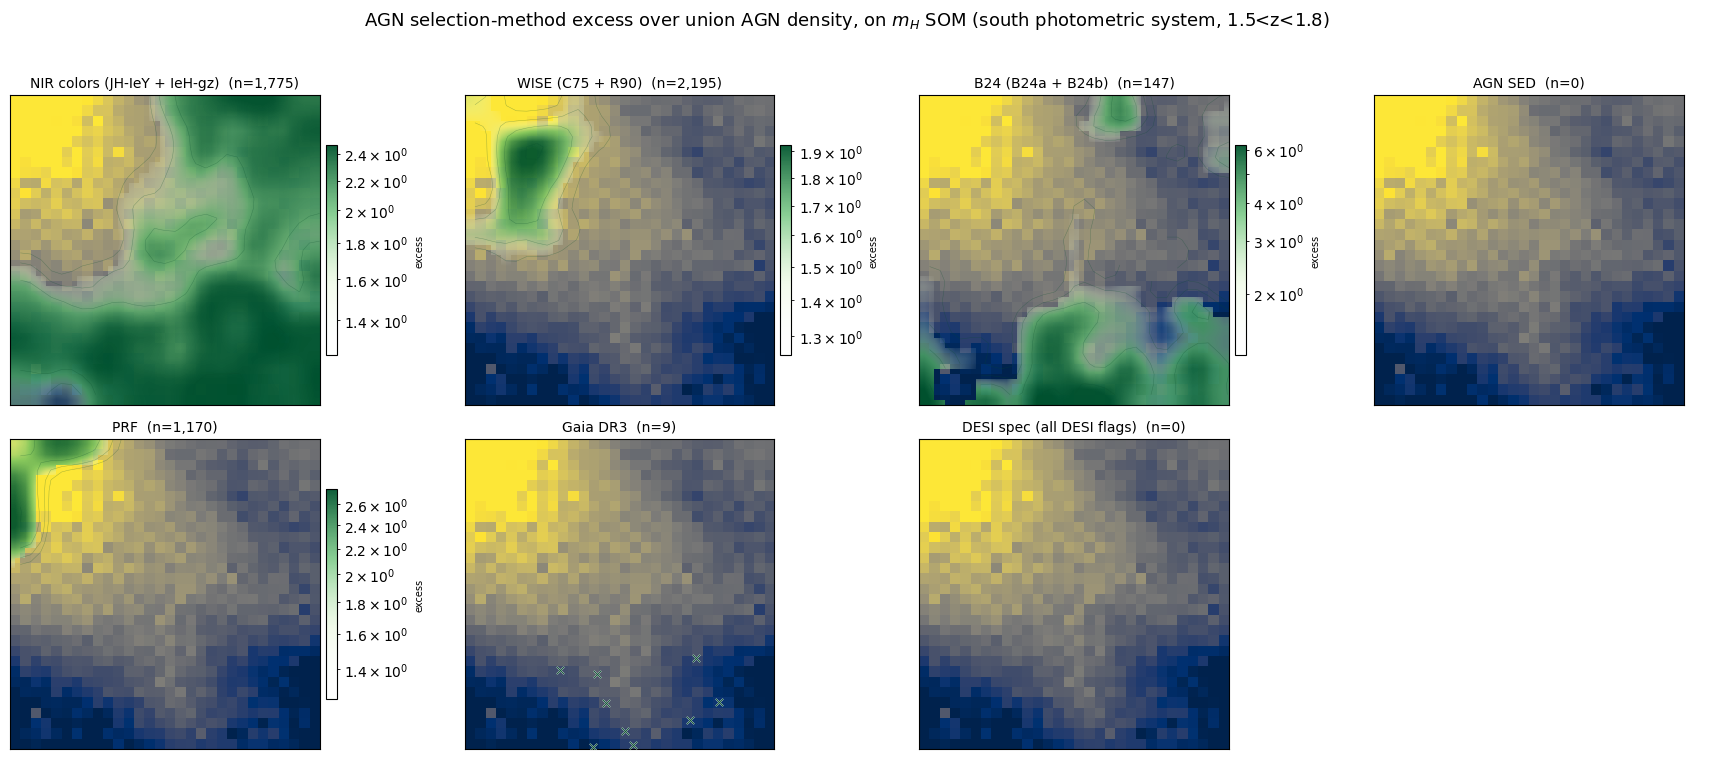

Method-excess baseline: north photometric system, n=1,779 AGN inliers
  independent panel colorbars; BMU x markers shown for n <= 40


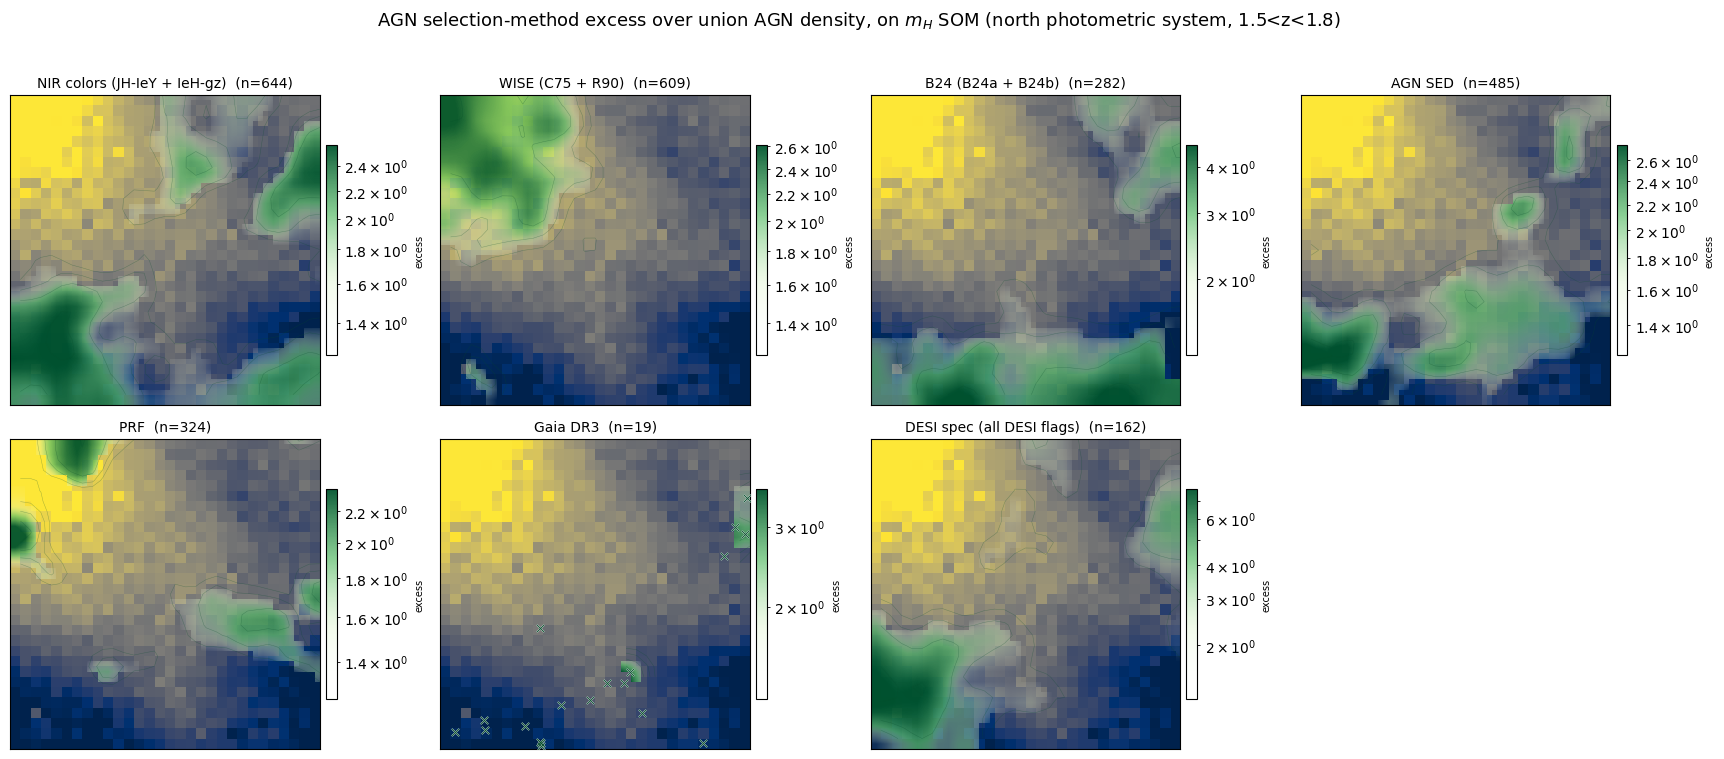

In [18]:
METHOD_POINT_N_MAX = 40         # show individual BMUs for sparse selections like Gaia DR3
METHOD_EXCESS_SYSTEMS = ['all', 'south', 'north']  # choose any of 'south', 'north', 'all'

mH_bg = fill_nan_nearest(med_mH)
method_systems = ([METHOD_EXCESS_SYSTEMS] if isinstance(METHOD_EXCESS_SYSTEMS, str)
                  else list(METHOD_EXCESS_SYSTEMS))

def plot_method_excess(system):
    if system == 'all':
        method_base_mask = np.ones(len(agn_in), dtype=bool)
        method_system_label = 'all photometric systems'
        method_save_suffix = 'all'
    else:
        method_base_mask = np.asarray(agn_in['phot_system'], dtype=str) == system
        method_system_label = f'{system} photometric system'
        method_save_suffix = system

    H_union = bmu_density(bmu_in, method_base_mask)
    print(f'Method-excess baseline: {method_system_label}, n={int(method_base_mask.sum()):,} AGN inliers')

    ncols = 4
    nrows = int(np.ceil(len(GROUPS) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.35*ncols, 3.7*nrows), squeeze=False)
    fig.subplots_adjust(wspace=0.38, hspace=0.24)
    print(f'  independent panel colorbars; BMU x markers shown for n <= {METHOD_POINT_N_MAX}')
    for k, (name, flags) in enumerate(GROUPS.items()):
        ax = axes[k//ncols, k%ncols]
        ax.imshow(mH_bg, origin='lower', cmap='cividis_r', vmin=mH_lo, vmax=mH_hi)
        msk = method_base_mask & group_mask(agn_in, flags)
        H = bmu_density(bmu_in, msk)
        im = overlay_method_excess(ax, H, H_union)
        if im is not None:
            add_panel_colorbar(fig, ax, im)
        n_method = int(msk.sum())
        if 0 < n_method <= METHOD_POINT_N_MAX:
            x_src, y_src = jitter_bmu(bmu_in[msk], seed=RANDOM_SEED + 1000 + k)
            ax.scatter(x_src, y_src, marker='x', s=28, linewidths=1.15,
                       color='white', alpha=0.95, zorder=5)
            ax.scatter(x_src, y_src, marker='x', s=28, linewidths=0.75,
                       color=METHOD_CONTOUR_COLOR, alpha=0.95, zorder=6)
        ax.set_title(f'{name}  (n={n_method:,})', fontsize=10)
        ax.set_xlim(-0.5, MSZ[1]-0.5); ax.set_ylim(-0.5, MSZ[0]-0.5)
        ax.set_xticks([]); ax.set_yticks([])
    for k in range(len(GROUPS), nrows*ncols):
        axes[k//ncols, k%ncols].axis('off')
    fig.suptitle(r'AGN selection-method excess over union AGN density, on $m_H$ SOM '
                 + f'({method_system_label}, {Z_WIN[0]}<z<{Z_WIN[1]})', y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()

for system in method_systems:
    plot_method_excess(system)


**Figure 3.** Method-specific excess on the $m_H$ SOM. Green regions mark cells where a selection method is locally overrepresented compared with the combined union-AGN distribution. Each populated panel has its own colorbar/range; for sparse selections (`n <= 40`), x markers show the individual BMUs.


## 9. Compare host-brightness distributions

The final 1D view checks whether method differences seen on the SOM also appear as shifts in observed $m_H$.


/Users/shemmati/Dropbox/euclid_q1_notebooks/.conda/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


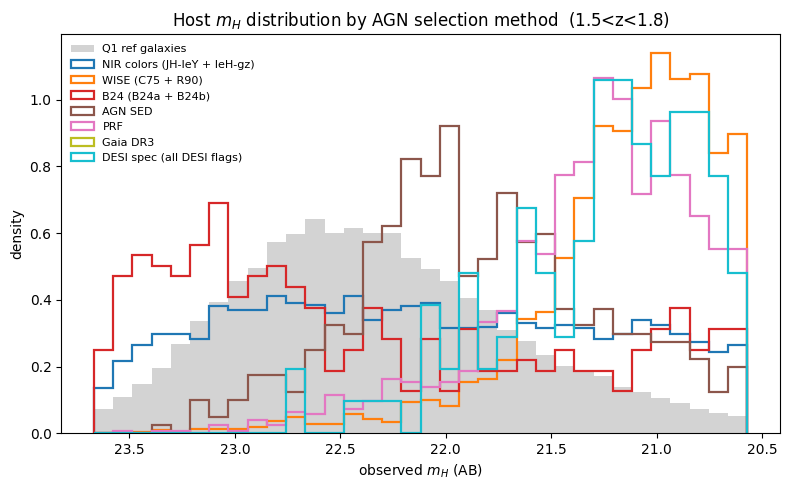

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

# Auto-range from training-set finite values
v_train = as_float_array(train_use['mH_obs'])
v_train = v_train[np.isfinite(v_train)]
rng_lo, rng_hi = np.nanpercentile(v_train, [1, 99])
bins = np.linspace(rng_lo, rng_hi, 35)

ax.hist(v_train, bins=bins, color='lightgrey', density=True, label='Q1 ref galaxies')

colors = plt.cm.tab10(np.linspace(0, 1, len(GROUPS)))
for (name, flags), c in zip(GROUPS.items(), colors):
    msk = group_mask(agn_in, flags)
    if msk.sum() < 10:
        continue
    v = as_float_array(agn_in['mH_obs'][msk])
    v = v[np.isfinite(v)]
    if v.size == 0:
        continue
    ax.hist(v, bins=bins, histtype='step', density=True, color=c, linewidth=1.6, label=name)

ax.invert_xaxis()  # brighter (lower mH) to the right -> intuitive "more massive = right"
ax.set_xlabel(r'observed $m_H$ (AB)')
ax.set_ylabel('density')
ax.legend(fontsize=8, loc='upper left', frameon=False)
ax.set_title(f'Host $m_H$ distribution by AGN selection method  ({Z_WIN[0]}<z<{Z_WIN[1]})', fontsize=12)
plt.tight_layout()
plt.show()

**Figure 4.** Observed $m_H$ distributions for the reference galaxies and each AGN selection group. Lower $m_H$ means brighter in the observed H band.


## What to take away

- The SOM provides a compact manifold-learning view of six-color Q1 photometry. Checking the input colors first makes the learned map easier to interpret.
- In this redshift slice, AGN candidates extend to redder `Y-J` and `J-H` colors than the reference galaxies, placing many selections in coherent regions of the color manifold.
- Projecting multiple AGN selections onto the same SOM shows where methods overlap and where individual techniques emphasize different parts of the manifold.
- The method-excess maps are a relative comparison: they highlight local enrichment of each technique after accounting for the overall union AGN distribution in the same photometric-system subset.
- The $m_H$ background adds an observed-frame host-brightness context for the SOM locations; it is not a stellar mass estimate.

Natural extensions are to train a balanced north+south SOM with `photometric_system` retained as metadata, or to train a NISP-focused SOM to isolate the Euclid-only color contribution.


## 10. Query Euclid spectra and inspect Halpha

This optional section connects the SOM projection to Euclid Q1 spectroscopy. It uses the 1D SIR spectra for a small visual spot check, following the [IRSA Euclid spectra access pattern](https://caltech-ipac.github.io/irsa-tutorials/euclid-clusters-tutorial/), and uses the SPE line-feature catalog for quantitative Halpha measurements, following the [IRSA SPE catalog tutorial](https://caltech-ipac.github.io/irsa-tutorials/euclid-intro-spe-catalog/).

The spectra plot is intentionally limited to a few examples so the notebook remains interactive. The quantitative figure compares cataloged SPE Gaussian-fit Halpha fluxes (`spe_line_flux_gf`) for the reference-galaxy control sample and for AGNs on the same SOM, without splitting north and south photometric systems. This keeps the workflow focused on how manifold position relates to spectroscopic line measurements, while leaving detailed line-profile modeling to specialized analyses.


In [20]:
# Spectra cache + IRSA SAS helpers (query_spectrum_associations,
# read_spectra_from_associations, get_n_spectra_for_table, etc.) are imported
# from agn_tutorial_utils. Cache directory and IRSA table constants are also
# defined there; the cache directory is ensured to exist at import time.
print(f'Spectra cache dir: {SPECTRA_CACHE_DIR}')
print(f'SAS association table: {SPECTRA_ASSOC_TABLE}')
print(f'SPE line-feature table: {SPE_LINES_TABLE}')


Spectra cache dir: data/irsa_spectra_agn
SAS association table: euclid.objectid_spectrafile_association_q1
SPE line-feature table: euclid_q1_spe_lines_line_features


Skipped 12 association rows with missing/invalid HDU indices.


Opening spectrum FITS files:   3%|▎         | 4/129 [04:33<2:22:23, 68.35s/file] 


AGN spectra retrieved for visual Halpha check: 5


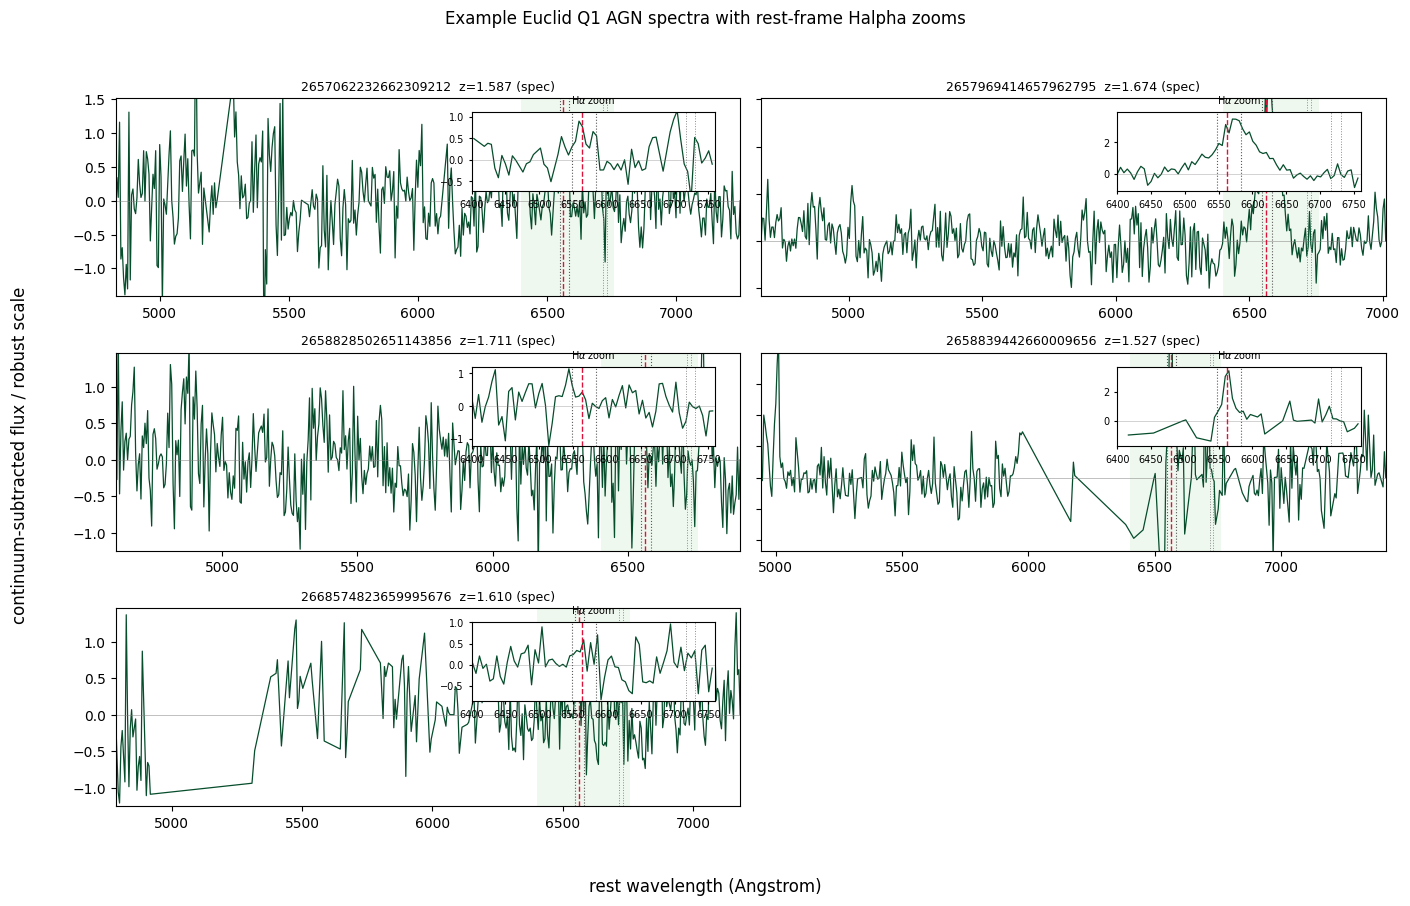

In [21]:
SPEC_EXAMPLE_N = 5
SPEC_EXAMPLE_MAX_IDS = 150

agn_example_spectra = get_n_spectra_for_table(
    agn_in,
    n=SPEC_EXAMPLE_N,
    max_ids=SPEC_EXAMPLE_MAX_IDS,
    prefer_spec_z=True,
)
print(f'AGN spectra retrieved for visual Halpha check: {len(agn_example_spectra)}')

def plot_halpha_examples(spectra, tab, max_panels=5, rest_window=(6400, 6760)):
    if len(spectra) == 0:
        print('No spectra available to plot.')
        return None
    rows = row_lookup_by_object_id(tab)
    object_ids = list(spectra.keys())[:max_panels]
    ncols = 2
    nrows = int(np.ceil(len(object_ids) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(7.1*ncols, 3.0*nrows), squeeze=False)
    for k, (ax, object_id) in enumerate(zip(axes.ravel(), object_ids)):
        row = rows.get(int(object_id))
        if row is None or not np.isfinite(row['z_final']):
            ax.axis('off')
            continue
        z = float(row['z_final'])
        norm = continuum_normalized_rest_spectrum(spectra[object_id], z)
        if norm is None:
            ax.text(0.5, 0.5, 'no usable spectrum', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{object_id}', fontsize=9)
            continue
        rest, y = norm
        ax.plot(rest, y, color='#064d2c', lw=0.9)
        ax.axhline(0, color='0.5', lw=0.7, alpha=0.5)
        ax.axvspan(rest_window[0], rest_window[1], color='#82c77a', alpha=0.12, lw=0)
        mark_halpha_complex(ax, full_range=True)
        ylo, yhi = np.nanpercentile(y, [1, 99])
        if np.isfinite(ylo) and np.isfinite(yhi) and ylo < yhi:
            pad = 0.08 * (yhi - ylo)
            ax.set_ylim(ylo - pad, yhi + pad)
        ax.set_xlim(np.nanmin(rest), np.nanmax(rest))
        ax.set_title(f'{object_id}  z={z:.3f} ({row["z_source"]})', fontsize=9)
        if k % ncols != 0:
            ax.set_yticklabels([])

        axins = ax.inset_axes([0.57, 0.53, 0.39, 0.40])
        zoom = (rest > rest_window[0]) & (rest < rest_window[1])
        if np.sum(zoom) >= 8:
            axins.plot(rest[zoom], y[zoom], color='#064d2c', lw=0.9)
            axins.axhline(0, color='0.5', lw=0.55, alpha=0.45)
            mark_halpha_complex(axins, full_range=True)
            zylo, zyhi = np.nanpercentile(y[zoom], [2, 98])
            if np.isfinite(zylo) and np.isfinite(zyhi) and zylo < zyhi:
                zpad = 0.12 * (zyhi - zylo)
                axins.set_ylim(zylo - zpad, zyhi + zpad)
        else:
            axins.text(0.5, 0.5, 'no Halpha\ncoverage', ha='center', va='center',
                       fontsize=7, transform=axins.transAxes)
        axins.set_xlim(rest_window)
        axins.set_title(r'H$\alpha$ zoom', fontsize=7)
        axins.tick_params(labelsize=7, length=2)
    for ax in axes.ravel()[len(object_ids):]:
        ax.axis('off')
    fig.suptitle('Example Euclid Q1 AGN spectra with rest-frame Halpha zooms', y=0.995, fontsize=12)
    fig.supxlabel('rest wavelength (Angstrom)', y=0.01)
    fig.supylabel('continuum-subtracted flux / robust scale', x=0.01)
    plt.tight_layout(rect=[0.02, 0.03, 1.0, 0.97])
    plt.show()
    return fig

_ = plot_halpha_examples(agn_example_spectra, agn_in, max_panels=SPEC_EXAMPLE_N)


In [22]:
SPE_AGN_HALPHA_CACHE = os.path.join(DATA_DIR, 'tutorial_agn_spe_halpha.ecsv')
SPE_CONTROL_HALPHA_CACHE = os.path.join(DATA_DIR, 'tutorial_control_spe_halpha.ecsv')
SPE_AGN_HALPHA_BEST = os.path.join(DATA_DIR, 'tutorial_agn_spe_halpha_best.ecsv')
SPE_CONTROL_HALPHA_BEST = os.path.join(DATA_DIR, 'tutorial_control_spe_halpha_best.ecsv')
SPE_AGN_MAX_IDS = None      # None queries all AGN in the current redshift/SOM sample.
SPE_CONTROL_MAX_IDS = None  # Set e.g. 15000 for a faster tutorial run; None uses the full control sample.

agn_spe_meta = make_spe_meta_table(agn_in, 'object_id_euclid', 'z_final', z_source_col='z_source')
control_is_agn = np.isin(
    np.asarray(train_use['object_id'], dtype=np.int64),
    np.asarray(agn_in['object_id_euclid'], dtype=np.int64),
)
control_use = train_use[~control_is_agn]
bmu_control = bmu_full[~control_is_agn]
control_spe_meta = make_spe_meta_table(control_use, 'object_id', 'phz_median', z_source='phot')
print(f'Control sample for SPE Halpha: {len(control_use):,} reference galaxies '
      f'after excluding {int(np.sum(control_is_agn)):,} projected AGN IDs.')

spe_agn_halpha_rows = query_spe_halpha_measurements(
    np.asarray(agn_in['object_id_euclid'], dtype=np.int64),
    cache_path=SPE_AGN_HALPHA_CACHE,
    max_ids=SPE_AGN_MAX_IDS,
    force_refresh=FORCE_REFRESH,
)
agn_halpha_meas = strongest_spe_halpha_per_object(spe_agn_halpha_rows, agn_spe_meta)

spe_control_halpha_rows = query_spe_halpha_measurements(
    np.asarray(control_use['object_id'], dtype=np.int64),
    cache_path=SPE_CONTROL_HALPHA_CACHE,
    max_ids=SPE_CONTROL_MAX_IDS,
    force_refresh=FORCE_REFRESH,
)
control_halpha_meas = strongest_spe_halpha_per_object(spe_control_halpha_rows, control_spe_meta)

print(f'AGN SPE Halpha line rows: {len(spe_agn_halpha_rows):,}')
print(f'AGN with positive SPE Halpha flux: {len(agn_halpha_meas):,}')
print(f'Control SPE Halpha line rows: {len(spe_control_halpha_rows):,}')
print(f'Control sources with positive SPE Halpha flux: {len(control_halpha_meas):,}')
if len(agn_halpha_meas) > 0:
    agn_halpha_meas.write(SPE_AGN_HALPHA_BEST, format='ascii.ecsv', overwrite=True)
    print(f'Saved {SPE_AGN_HALPHA_BEST}')
if len(control_halpha_meas) > 0:
    control_halpha_meas.write(SPE_CONTROL_HALPHA_BEST, format='ascii.ecsv', overwrite=True)
    print(f'Saved {SPE_CONTROL_HALPHA_BEST}')


Control sample for SPE Halpha: 47,074 reference galaxies after excluding 1,797 projected AGN IDs.
Loaded cached SPE Halpha measurements: 23,220 rows (data/tutorial_agn_spe_halpha.ecsv)
Loaded cached SPE Halpha measurements: 111,225 rows (data/tutorial_control_spe_halpha.ecsv)
AGN SPE Halpha line rows: 23,220
AGN with positive SPE Halpha flux: 2,977
Control SPE Halpha line rows: 111,225
Control sources with positive SPE Halpha flux: 14,515
Saved data/tutorial_agn_spe_halpha_best.ecsv
Saved data/tutorial_control_spe_halpha_best.ecsv


Control detections plotted: 5,561
AGN detections plotted: 1,180
Control occupied cells with no plotted Halpha detection are included as zero in the mean.
Blank control cells have no underlying control objects; AGN non-detections are plotted as zero-valued points.
The normalized histogram excludes zero-valued non-detections because it uses log flux.


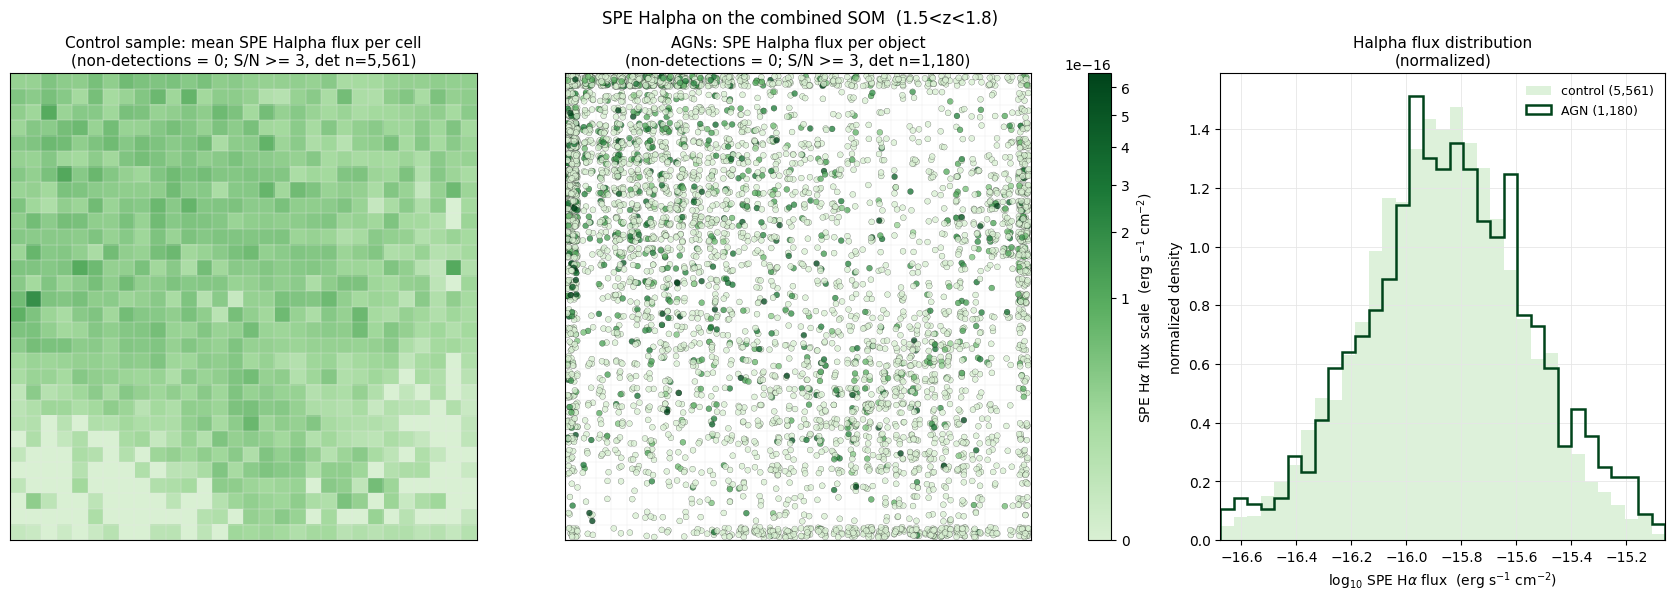

In [23]:
SPE_HALPHA_CMAP = LinearSegmentedColormap.from_list('spe_halpha_green', [
    '#d9f0d3', '#a6dba0', '#5aae61', '#1b7837', '#00441b'
])
SPE_HALPHA_CMAP.set_bad(color='white', alpha=1.0)

def plot_control_vs_agn_halpha_som(control_table, agn_table, snr_min=HALPHA_SNR_MIN):
    control_det = add_bmu_to_halpha(
        control_table, control_use, bmu_control, 'object_id', snr_min=snr_min, label='control'
    )
    agn_det = add_bmu_to_halpha(
        agn_table, agn_in, bmu_in, 'object_id_euclid', snr_min=snr_min, label='AGN'
    )
    control_flux_grid, control_total = mean_metric_grid_including_zeros(
        bmu_control, control_det, 'halpha_flux'
    )
    agn_flux_all = np.zeros(len(agn_in), dtype=float)
    if len(agn_det) > 0:
        agn_flux_by_id = {
            int(obj): float(flux)
            for obj, flux in zip(agn_det['object_id_euclid'], agn_det['halpha_flux'])
            if np.isfinite(flux) and flux > 0
        }
        agn_flux_all = np.array([
            agn_flux_by_id.get(int(obj), 0.0) for obj in agn_in['object_id_euclid']
        ], dtype=float)
    norm = halpha_flux_scale_norm(control_flux_grid, agn_flux_all)
    if norm is None:
        print('No positive SPE Halpha fluxes to show for either sample.')
        return None

    fig, axes = plt.subplots(
        1, 3, figsize=(17.4, 5.9), constrained_layout=True,
        gridspec_kw={'width_ratios': [1.0, 1.0, 0.82]},
    )
    for ax in axes[:2]:
        format_empty_som_axis(ax)
        ax.set_aspect('equal', adjustable='box')

    if np.any(np.isfinite(control_flux_grid)):
        axes[0].imshow(np.ma.masked_invalid(control_flux_grid), origin='lower', cmap=SPE_HALPHA_CMAP,
                       norm=norm, interpolation='nearest')
    else:
        axes[0].text(0.5, 0.5, 'no control Halpha measurements', ha='center', va='center',
                     transform=axes[0].transAxes, fontsize=10)
    axes[0].set_title(f'Control sample: mean SPE Halpha flux per cell\n(non-detections = 0; S/N >= {snr_min:g}, det n={len(control_det):,})', fontsize=11)

    if len(agn_in) > 0:
        x_agn, y_agn = jitter_bmu(bmu_in)
        axes[1].scatter(x_agn, y_agn, c=agn_flux_all, cmap=SPE_HALPHA_CMAP, norm=norm,
                        marker='o', s=18, edgecolors='black', linewidths=0.18, alpha=0.78)
    else:
        axes[1].text(0.5, 0.5, 'no AGN Halpha measurements', ha='center', va='center',
                     transform=axes[1].transAxes, fontsize=10)
    axes[1].set_title(f'AGNs: SPE Halpha flux per object\n(non-detections = 0; S/N >= {snr_min:g}, det n={len(agn_det):,})', fontsize=11)

    control_hist = log_flux_values(control_det)
    agn_hist = log_flux_values(agn_det)
    hist_vals = np.concatenate([v for v in [control_hist, agn_hist] if v.size])
    if hist_vals.size > 1:
        hlo, hhi = np.nanpercentile(hist_vals, [1, 99]) if hist_vals.size > 20 else (np.nanmin(hist_vals), np.nanmax(hist_vals))
        if not np.isfinite(hlo) or not np.isfinite(hhi) or hlo == hhi:
            center = float(np.nanmedian(hist_vals))
            hlo, hhi = center - 0.1, center + 0.1
        pad = 0.04 * (hhi - hlo)
        bins = np.linspace(hlo - pad, hhi + pad, 34)
        if control_hist.size:
            axes[2].hist(control_hist, bins=bins, density=True, histtype='stepfilled',
                         color='#a6dba0', alpha=0.38, label=f'control ({len(control_hist):,})')
        if agn_hist.size:
            axes[2].hist(agn_hist, bins=bins, density=True, histtype='step',
                         color='#00441b', linewidth=1.8, label=f'AGN ({len(agn_hist):,})')
        axes[2].set_xlim(bins[0], bins[-1])
    else:
        axes[2].text(0.5, 0.5, 'no Halpha distribution', ha='center', va='center',
                     transform=axes[2].transAxes, fontsize=10)
    axes[2].set_title('Halpha flux distribution\n(normalized)', fontsize=11)
    axes[2].set_xlabel(r'log$_{10}$ SPE H$\alpha$ flux  (erg s$^{-1}$ cm$^{-2}$)')
    axes[2].set_ylabel('normalized density')
    axes[2].grid(color='0.90', linewidth=0.6)
    axes[2].legend(frameon=False, fontsize=9)

    mappable = plt.cm.ScalarMappable(norm=norm, cmap=SPE_HALPHA_CMAP)
    mappable.set_array([])
    cbar = fig.colorbar(mappable, ax=list(axes[:2]), fraction=0.035, pad=0.03)
    cbar.set_label(r'SPE H$\alpha$ flux scale  (erg s$^{-1}$ cm$^{-2}$)')
    fig.suptitle(f'SPE Halpha on the combined SOM  ({Z_WIN[0]}<z<{Z_WIN[1]})', fontsize=12)
    print(f'Control detections plotted: {len(control_det):,}')
    print(f'AGN detections plotted: {len(agn_det):,}')
    print('Control occupied cells with no plotted Halpha detection are included as zero in the mean.')
    print('Blank control cells have no underlying control objects; AGN non-detections are plotted as zero-valued points.')
    print('The normalized histogram excludes zero-valued non-detections because it uses log flux.')
    plt.show()
    return fig

_ = plot_control_vs_agn_halpha_som(control_halpha_meas, agn_halpha_meas, snr_min=HALPHA_SNR_MIN)


### Halpha luminosity, EW, and detection fraction

Observed line flux is only one view of the spectroscopy. The next diagnostic converts SPE Halpha fluxes to luminosities using the sample redshift, maps SPE equivalent width, and shows the fraction of sources in each SOM cell with a positive SPE Halpha measurement. Cell averages include non-detections as zero; cells with no underlying sample objects remain blank.


Mean luminosity and EW maps include non-detections as zero within occupied SOM cells.
Blank cells have no underlying sample objects in that row.


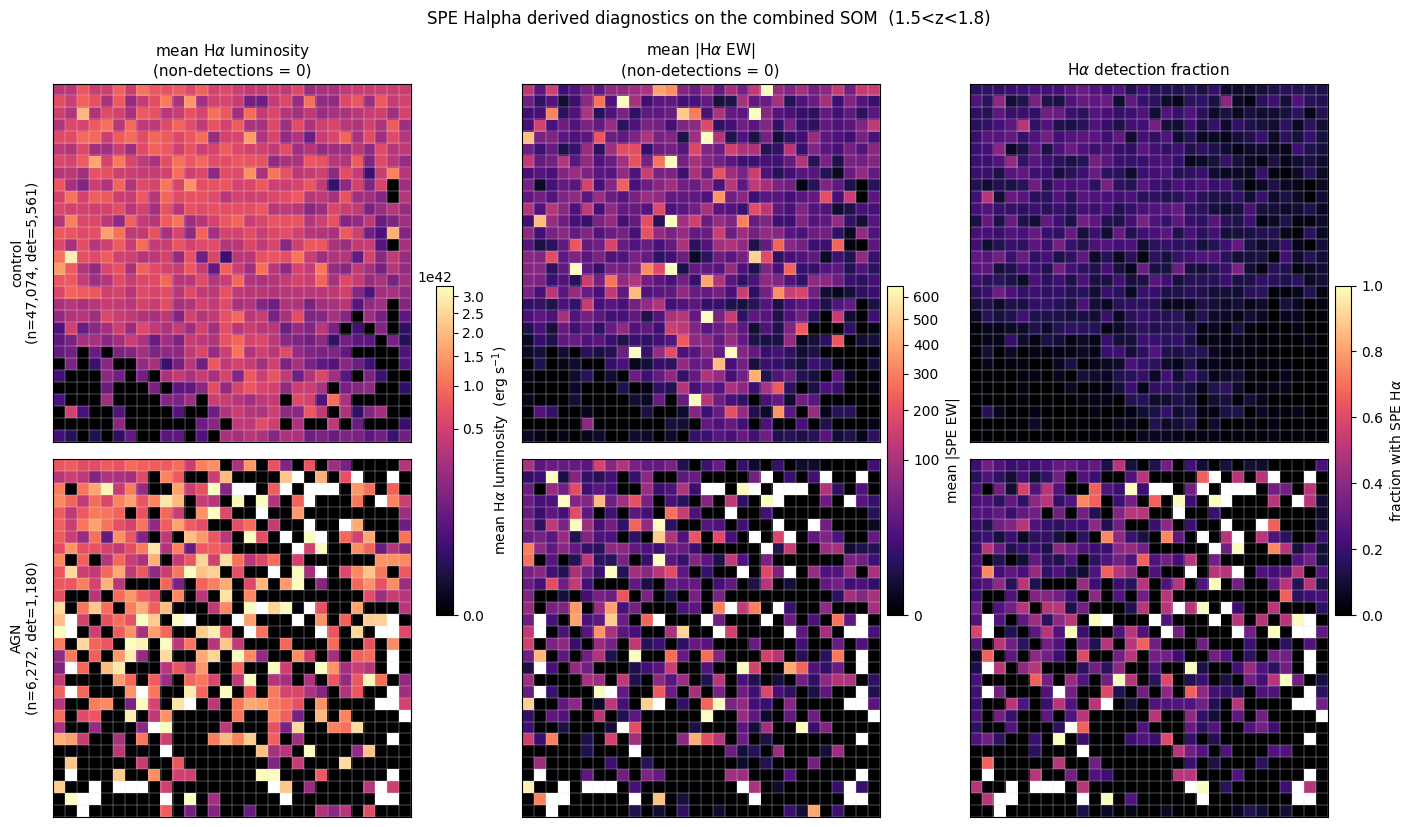

In [24]:
def plot_halpha_luminosity_ew_fraction_maps(control_table, agn_table, snr_min=HALPHA_SNR_MIN):
    control_table = ensure_halpha_luminosity(control_table)
    agn_table = ensure_halpha_luminosity(agn_table)
    control_det = add_bmu_to_halpha(
        control_table, control_use, bmu_control, 'object_id', snr_min=snr_min, label='control'
    )
    agn_det = add_bmu_to_halpha(
        agn_table, agn_in, bmu_in, 'object_id_euclid', snr_min=snr_min, label='AGN'
    )

    control_lum, control_total = mean_metric_grid_including_zeros(
        bmu_control, control_det, 'halpha_luminosity'
    )
    agn_lum, agn_total = mean_metric_grid_including_zeros(
        bmu_in, agn_det, 'halpha_luminosity'
    )
    control_ew, _ = mean_metric_grid_including_zeros(
        bmu_control, control_det, 'halpha_ew', value_transform=np.abs
    )
    agn_ew, _ = mean_metric_grid_including_zeros(
        bmu_in, agn_det, 'halpha_ew', value_transform=np.abs
    )
    control_frac, _, control_detected = detection_fraction_grid(bmu_control, control_det)
    agn_frac, _, agn_detected = detection_fraction_grid(bmu_in, agn_det)

    lum_norm = power_norm_from_grids(control_lum, agn_lum, gamma=0.30, pct=98)
    ew_norm = power_norm_from_grids(control_ew, agn_ew, gamma=0.40, pct=98)
    frac_norm = Normalize(vmin=0.0, vmax=1.0)

    fig, axes = plt.subplots(2, 3, figsize=(14.0, 8.2), constrained_layout=True)
    row_labels = [
        f'control\n(n={int(np.nansum(control_total)):,}, det={int(np.nansum(control_detected)):,})',
        f'AGN\n(n={int(np.nansum(agn_total)):,}, det={int(np.nansum(agn_detected)):,})',
    ]
    maps = [
        (control_lum, agn_lum, lum_norm, 'mean H$\\alpha$ luminosity\n(non-detections = 0)', r'mean H$\alpha$ luminosity  (erg s$^{-1}$)'),
        (control_ew, agn_ew, ew_norm, 'mean |H$\\alpha$ EW|\n(non-detections = 0)', 'mean |SPE EW|'),
        (control_frac, agn_frac, frac_norm, r'H$\alpha$ detection fraction', r'fraction with SPE H$\alpha$'),
    ]

    images = []
    for col, (control_grid, agn_grid, norm, title, cbar_label) in enumerate(maps):
        im0 = axes[0, col].imshow(np.ma.masked_invalid(control_grid), origin='lower',
                                  cmap=HALPHA_DERIVED_CMAP, norm=norm, interpolation='nearest')
        im1 = axes[1, col].imshow(np.ma.masked_invalid(agn_grid), origin='lower',
                                  cmap=HALPHA_DERIVED_CMAP, norm=norm, interpolation='nearest')
        images.append((im0, cbar_label))
        axes[0, col].set_title(title, fontsize=11)
        for ax in axes[:, col]:
            format_empty_som_axis(ax)
            ax.set_aspect('equal', adjustable='box')
    for row, label in enumerate(row_labels):
        axes[row, 0].set_ylabel(label, fontsize=10)
    for col, (im, cbar_label) in enumerate(images):
        cbar = fig.colorbar(im, ax=list(axes[:, col]), fraction=0.046, pad=0.02)
        cbar.set_label(cbar_label)
    fig.suptitle(f'SPE Halpha derived diagnostics on the combined SOM  ({Z_WIN[0]}<z<{Z_WIN[1]})', fontsize=12)
    print('Mean luminosity and EW maps include non-detections as zero within occupied SOM cells.')
    print('Blank cells have no underlying sample objects in that row.')
    plt.show()
    return fig

_ = plot_halpha_luminosity_ew_fraction_maps(control_halpha_meas, agn_halpha_meas, snr_min=HALPHA_SNR_MIN)
